<a href="https://colab.research.google.com/github/Rufidatul726/6thSemester/blob/temp/AggregateQuery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define RawSC function
def RawSC(D, A, f, k):
    sample = D.sample(k)
    return getattr(sample[A], f)()

In [3]:
# Define NormalizedSC function
def NormalizedSC(D, A, f, k):
    sample = D.sample(k)
    ratio = len(D) / len(sample)
    return RawSC(D, A, f, k) * ratio

In [4]:
# Load datasets
clean_data = pd.read_csv('adult.csv')
dirty_data = pd.read_csv('adult-with-error.csv')

In [5]:
# Find accurate age values using record ids
accurate_ages = clean_data.set_index('rid')['age'].to_dict()
dirty_data['accurate_age'] = dirty_data['duplicate'].map(accurate_ages)

In [6]:
# Define experiment parameters
sample_sizes = [100, 1000, 2000, 5000, 10000, 20000]
num_experiments = 5

In [7]:
# Perform experiments
results_rawsc = {}
results_normalizedsc = {}

for k in sample_sizes:
    errors_rawsc = []
    errors_normalizedsc = []

    for _ in range(num_experiments):
        est_sum_rawsc = RawSC(dirty_data, 'accurate_age', 'sum', k)
        est_sum_normalizedsc = NormalizedSC(dirty_data, 'accurate_age', 'sum', k)

        true_sum = clean_data['age'].sum()

        error_rawsc = abs(est_sum_rawsc - true_sum)
        error_normalizedsc = abs(est_sum_normalizedsc - true_sum)

        errors_rawsc.append(error_rawsc)
        errors_normalizedsc.append(error_normalizedsc)

    mean_error_rawsc = np.mean(errors_rawsc)
    std_error_rawsc = np.std(errors_rawsc)

    mean_error_normalizedsc = np.mean(errors_normalizedsc)
    std_error_normalizedsc = np.std(errors_normalizedsc)

    results_rawsc[k] = (mean_error_rawsc, std_error_rawsc)
    results_normalizedsc[k] = (mean_error_normalizedsc, std_error_normalizedsc)


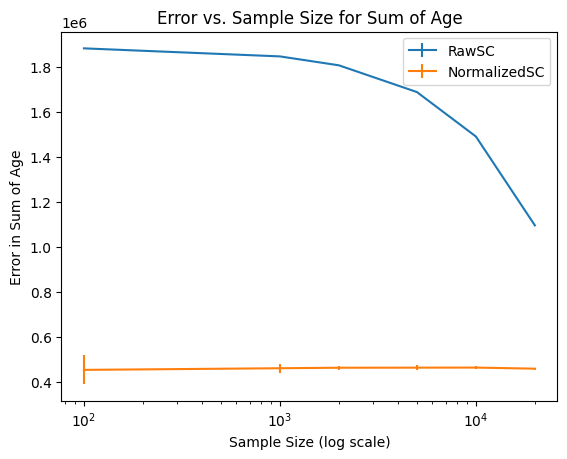

In [8]:
# Plot results
plt.errorbar(list(results_rawsc.keys()), [mean for mean, _ in results_rawsc.values()], yerr=[std for _, std in results_rawsc.values()], label='RawSC')
plt.errorbar(list(results_normalizedsc.keys()), [mean for mean, _ in results_normalizedsc.values()], yerr=[std for _, std in results_normalizedsc.values()], label='NormalizedSC')
plt.xscale('log')
plt.xlabel('Sample Size (log scale)')
plt.ylabel('Error in Sum of Age')
plt.title('Error vs. Sample Size for Sum of Age')
plt.legend()
plt.show()

In [1]:
!pip install syft
!pip install torch
!pip install numpy

In [2]:
import syft as sy
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# Load clean dataset
clean_data = pd.read_csv('adult.csv')

# Encode the target variable 'income'
label_encoder = LabelEncoder()
clean_data['income'] = label_encoder.fit_transform(clean_data['income'])

# Identify categorical columns
categorical_cols = clean_data.select_dtypes(include=['object']).columns

# One-hot encode categorical columns
clean_data = pd.get_dummies(clean_data, columns=categorical_cols, drop_first=True)

# Split the dataset into features and target
X = clean_data.drop('income', axis=1)
y = clean_data['income']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [10]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [11]:
# Define a differentially private logistic regression model
class DPLogisticRegression(nn.Module):
    def __init__(self, input_size):
        super(DPLogisticRegression, self).__init__()
        self.linear = nn.Linear(input_size, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

In [12]:
# Function to train a differentially private model
def train(model, train_loader, epochs, epsilon):
    criterion = nn.BCELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        for data, labels in train_loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, labels.unsqueeze(1))
            loss.backward()

            # Add differential privacy noise
            for param in model.parameters():
                param.grad += torch.tensor(np.random.normal(0, epsilon, param.grad.shape), dtype=torch.float32)

            optimizer.step()

In [13]:
# Function to evaluate the model
def evaluate(model, test_loader):
    model.eval()
    predictions = []

    with torch.no_grad():
        for data, labels in test_loader:
            output = model(data)
            predictions.extend(output.round().squeeze().tolist())

    return predictions

In [14]:
# Experiment with different privacy budgets
privacy_budgets = [0.0001, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
accuracies = []

for epsilon in privacy_budgets:
    # Instantiate the differentially private model
    model = DPLogisticRegression(input_size=X.shape[1])

    # Train the model
    train(model, train_loader, epochs=10, epsilon=epsilon)

    # Evaluate the model
    predictions = evaluate(model, test_loader)
    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)

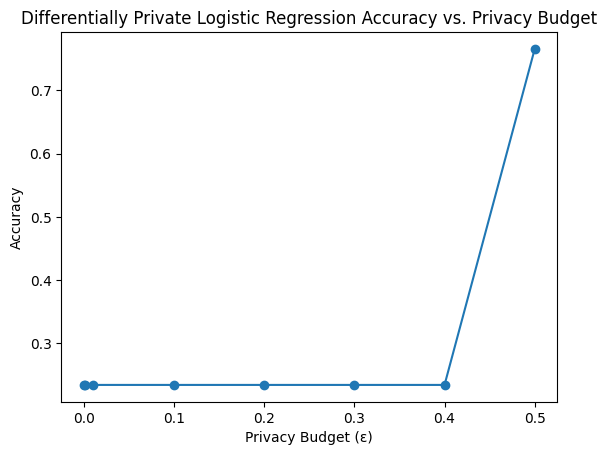

In [15]:
# Plot the results
plt.plot(privacy_budgets, accuracies, marker='o')
plt.xlabel('Privacy Budget (ε)')
plt.ylabel('Accuracy')
plt.title('Differentially Private Logistic Regression Accuracy vs. Privacy Budget')
plt.show()